# Segmentation (어떤 고객)
- 세그먼트별 완료율 히트맵 + 카이제곱

## 1. 환경 설정 + 데이터 로드

In [1]:
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportion_confint

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_columns", None)

# OS별 한글 폰트
_font = {"Darwin": "AppleGothic", "Windows": "Malgun Gothic"}.get(platform.system(), "NanumGothic")
plt.rcParams.update({"font.family": _font, "axes.unicode_minus": False})

# 경로 설정
DATA_DIR = "../pjh_EDA/"
FUNNEL_FILE = DATA_DIR + "funnel_instance.csv"
FULL_FILE = DATA_DIR + "preprocessed_final.csv"

# 세그먼트 순서
INC_ORDER = ["5만 미만", "5-7.5만", "7.5-10만", "10만 이상"]
AGE_ORDER = ["20대 미만", "20대", "30대", "40대", "50대", "60대 이상"]

print("환경 설정 완료")

환경 설정 완료


## 2. 데이터 로드 + 속성 병합

In [2]:
full = pd.read_csv(FULL_FILE)
funnel = pd.read_csv(FUNNEL_FILE)

# 오퍼 속성 병합 (offer_type, duration은 이미 CSV에 있으므로 제외)
offer_attr = (
    full[["offer_id", "difficulty", "reward", "ch_email", "ch_web", "ch_mobile", "ch_social", "channel_count"]]
    .dropna(subset=["offer_id"])
    .drop_duplicates("offer_id")
)
# 고객 속성 병합
cust_attr = full[["customer_id", "gender", "age_group", "income_group", "income"]].drop_duplicates("customer_id")

funnel = funnel.merge(offer_attr, on="offer_id", how="left", validate="m:1")
funnel = funnel.merge(cust_attr, on="customer_id", how="left", validate="m:1")

assert len(funnel) == 76277, f"행 수 불일치: {len(funnel)}"
print(f"funnel shape: {funnel.shape}  ✓ 행 수 불변")

# 분석용 서브셋: bogo/discount + 누락 제거
funnel_clean = funnel[
    funnel["offer_type"].isin(["bogo", "discount"])
    & funnel["income_group"].isin(INC_ORDER)
    & funnel["age_group"].isin(AGE_ORDER)
].copy()

print(f"funnel_clean: {len(funnel_clean):,}건 " f"(전체 {len(funnel):,}건의 {len(funnel_clean)/len(funnel)*100:.1f}%)")

funnel shape: (76277, 39)  ✓ 행 수 불변
funnel_clean: 53,201건 (전체 76,277건의 69.7%)


In [3]:
# 세그먼트별 is_aware 기반 마케팅 전환율
# 완료율(is_completed)과 인지완료율(is_aware) 비교
# 차이 = 미인지 완료 비율 → 마케팅 효과 없이 달성된 비율

print("[ 소득 구간별 완료율 vs 인지완료율 ]")
for inc in INC_ORDER:
    sub = funnel_clean[funnel_clean["income_group"] == inc]
    n = len(sub)
    comp_rate = sub["is_completed"].mean() * 100
    aware_rate = sub["is_aware"].mean() * 100
    unaware = comp_rate - aware_rate
    print(
        f"  {inc:<10} 완료율 {comp_rate:.1f}%  "
        f"인지완료 {aware_rate:.1f}%  "
        f"미인지완료 {unaware:.1f}%p  (n={n:,})"
    )

print("\n[ 연령대별 완료율 vs 인지완료율 ]")
for age in AGE_ORDER:
    sub = funnel_clean[funnel_clean["age_group"] == age]
    n = len(sub)
    comp_rate = sub["is_completed"].mean() * 100
    aware_rate = sub["is_aware"].mean() * 100
    unaware = comp_rate - aware_rate
    print(
        f"  {age:<10} 완료율 {comp_rate:.1f}%  "
        f"인지완료 {aware_rate:.1f}%  "
        f"미인지완료 {unaware:.1f}%p  (n={n:,})"
    )

print("\n[ 성별 완료율 vs 인지완료율 ]")
for g in ["M", "F", "O"]:
    sub = funnel_clean[funnel_clean["gender"] == g]
    n = len(sub)
    comp_rate = sub["is_completed"].mean() * 100
    aware_rate = sub["is_aware"].mean() * 100
    unaware = comp_rate - aware_rate
    print(
        f"  {g:<5} 완료율 {comp_rate:.1f}%  " f"인지완료 {aware_rate:.1f}%  " f"미인지완료 {unaware:.1f}%p  (n={n:,})"
    )

[ 소득 구간별 완료율 vs 인지완료율 ]
  5만 미만      완료율 43.8%  인지완료 29.8%  미인지완료 14.0%p  (n=13,618)
  5-7.5만     완료율 59.4%  인지완료 43.1%  미인지완료 16.3%p  (n=23,152)
  7.5-10만    완료율 74.3%  인지완료 52.0%  미인지완료 22.3%p  (n=12,479)
  10만 이상     완료율 76.5%  인지완료 46.3%  미인지완료 30.3%p  (n=3,952)

[ 연령대별 완료율 vs 인지완료율 ]
  20대 미만     완료율 43.6%  인지완료 28.3%  미인지완료 15.4%p  (n=722)
  20대        완료율 47.0%  인지완료 31.2%  미인지완료 15.8%p  (n=4,997)
  30대        완료율 53.7%  인지완료 38.0%  미인지완료 15.7%p  (n=5,515)
  40대        완료율 58.1%  인지완료 43.7%  미인지완료 14.4%p  (n=8,241)
  50대        완료율 64.3%  인지완료 44.4%  미인지완료 19.9%p  (n=12,692)
  60대 이상     완료율 63.8%  인지완료 44.0%  미인지완료 19.9%p  (n=21,034)

[ 성별 완료율 vs 인지완료율 ]
  M     완료율 53.0%  인지완료 37.7%  미인지완료 15.3%p  (n=30,562)
  F     완료율 69.8%  인지완료 47.6%  미인지완료 22.2%p  (n=21,918)
  O     완료율 68.4%  인지완료 53.5%  미인지완료 14.8%p  (n=721)


### 소득
- 소득 높을수록 완료율 높음 ( 5만 미만 43.8% / 10만 이상 76.5%)
- 고소득(10만 이상)의 미인지완료가 30.3%로 가장 높음
     = 오퍼를 보지 않아도 자연스럽게 달성하는 비율이 제일 큰 그룹
     = 완료율 76.5% 중 실제 마케팅 효과는 46.3%
     = "고소득층은 오퍼 없이도 구매하는 고객"일 가능성

- 저소득(5만 미만)은 미인지완료 14.0%로 가장 낮음
  = 완료 자체가 어렵고, 완료하면 오퍼를 보고 완료했을 가능성이 높음
  = 마케팅 메시지가 저소득층에는 실제로 더 잘 작동하고 있는 것일 수 있음

### 성별
- F 69.8%  vs  M 53.0%  → 차이 16.8%

- 단순히 "여성이 오퍼를 더 잘 완료한다"가 아니라 F의 미인지완료(22.2%)가 M(15.3%)보다도 높음
= 여성은 오퍼를 보든 안 보든 완료율이 높음

- O는 표본(n=721)이 작아서 해석 주의

### 연령대
- 50대, 60대 이상이 완료율은 높지만 (62~64%) 미인지완료도 19.9%로 높음
= 중장년층도 자연 구매 비율이 높은 편

- 전 연령대에서 discount > bogo
- 특히 20대 미만: bogo 36.7% vs discount 51.3% → 격차 14.6%로 가장 큼

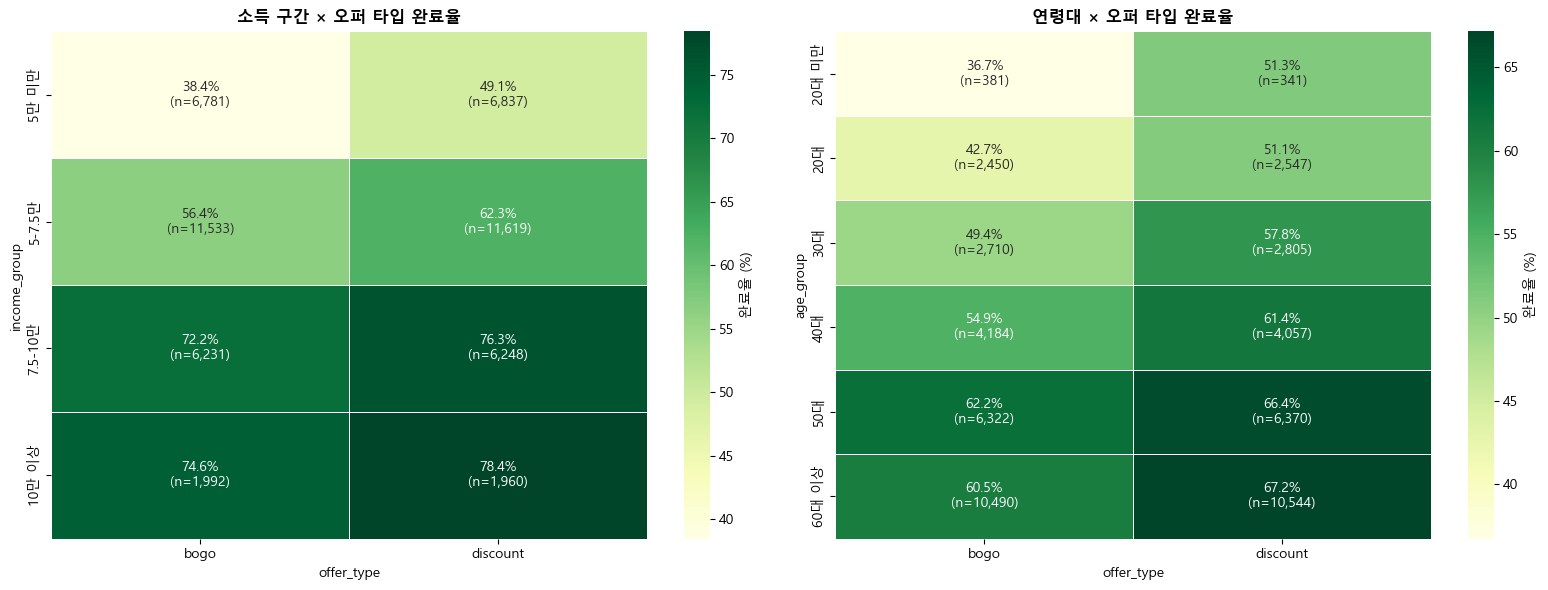

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 소득 구간 × 오퍼 타입
pivot_inc = (funnel_clean.groupby(["income_group", "offer_type"])["is_completed"].mean().unstack() * 100).reindex(
    INC_ORDER
)

n_inc = (funnel_clean.groupby(["income_group", "offer_type"])["is_completed"].count().unstack()).reindex(INC_ORDER)

annot_inc = pivot_inc.copy().astype(object)
for r in INC_ORDER:
    for c in pivot_inc.columns:
        rate = pivot_inc.loc[r, c]
        n = n_inc.loc[r, c]
        annot_inc.loc[r, c] = f"{rate:.1f}%\n(n={int(n):,})" if pd.notna(rate) else "-"

sns.heatmap(
    pivot_inc, annot=annot_inc, fmt="", cmap="YlGn", ax=axes[0], linewidths=0.5, cbar_kws={"label": "완료율 (%)"}
)
axes[0].set_title("소득 구간 × 오퍼 타입 완료율", fontweight="bold")

# 연령대 × 오퍼 타입
pivot_age = (funnel_clean.groupby(["age_group", "offer_type"])["is_completed"].mean().unstack() * 100).reindex(
    AGE_ORDER
)

n_age = (funnel_clean.groupby(["age_group", "offer_type"])["is_completed"].count().unstack()).reindex(AGE_ORDER)

annot_age = pivot_age.copy().astype(object)
for r in AGE_ORDER:
    for c in pivot_age.columns:
        rate = pivot_age.loc[r, c]
        n = n_age.loc[r, c]
        annot_age.loc[r, c] = f"{rate:.1f}%\n(n={int(n):,})" if pd.notna(rate) else "-"

sns.heatmap(
    pivot_age, annot=annot_age, fmt="", cmap="YlGn", ax=axes[1], linewidths=0.5, cbar_kws={"label": "완료율 (%)"}
)
axes[1].set_title("연령대 × 오퍼 타입 완료율", fontweight="bold")

plt.tight_layout()
plt.show()

In [5]:
# 소득 구간별로 받은 오퍼의 difficulty 분포 확인
print("[ 소득 구간별 difficulty 분포 ]")
funnel_clean.groupby("income_group")["difficulty"].describe().reindex(INC_ORDER)
# 모든 소득 구간의 difficulty 분포가 거의 동일
# 고소득층은 평소 구매 금액이 높아서 오퍼 조건을 자연스럽게 달성할 가능성이 높음

[ 소득 구간별 difficulty 분포 ]


,count,mean,std,min,25%,50%,75%,max
income_group,,,,,,,,
5만 미만,13618.00,9.67,4.49,5.00,7.00,10.00,10.00,20.00
5-7.5만,23152.00,9.62,4.44,5.00,7.00,10.00,10.00,20.00
7.5-10만,12479.00,9.65,4.47,5.00,7.00,10.00,10.00,20.00
10만 이상,3952.00,9.62,4.41,5.00,5.00,10.00,10.00,20.00


In [6]:
# 소득 구간별 평균 거래 금액 확인
# 고소득층이 평소에 difficulty를 쉽게 넘기는지
tx = full[full["event"] == "transaction"].copy()

print("[ 소득 구간별 평균 거래 금액 ]")
tx.groupby("income_group")["amount"].agg(["mean", "median", "count"]).reindex(INC_ORDER)

# 거래 금액 평균
# 5만 미만  : $6.68  = difficulty $10 달성 어려움
# 5~7.5만 부터 10만 이상 : $30.89 = 오퍼 보지 않아도 한 번 거래로 달성 가능

[ 소득 구간별 평균 거래 금액 ]


,mean,median,count
income_group,,,
5만 미만,6.68,4.45,37949
5-7.5만,12.32,10.45,56976
7.5-10만,25.65,22.14,22380
10만 이상,30.89,26.55,6652


저소득층 (5만 미만)
- 거래 금액 $6.68로 difficulty 달성이 어려움
- 오퍼를 봐야 의식적으로 구매를 늘릴 동기 생김
- 인지완료율이 상대적으로 높은 이유
- 마케팅 메시지가 실제로 행동 변화를 이끌어내는 구간

고소득층 (10만 이상)
- 거래 금액 $30.89로 difficulty를 자연스럽게 달성
- 오퍼 인지 없이도 완료되는 경우가 많음
- 마케팅 비용 대비 효율이 낮을 수 있음
- 이 구간에는 더 높은 difficulty 오퍼나 충성도 강화 목적의 오퍼가 더 적합할 수 있음

"그러면 고소득층에게 difficulty가 높은 오퍼를 주면 인지완료율이 올라갈까?"
--> 소득 구간 × difficulty 구간 × 완료율 교차 분석

In [7]:
# difficulty를 구간으로 나눠서
# 소득별로 낮은 난이도 오퍼 vs 높은 난이도 오퍼 완료율 비교
funnel_clean["difficulty_group"] = pd.cut(
    funnel_clean["difficulty"], bins=[0, 6, 9, 10], labels=["낮음(<7)", "중간(7~9)", "높음(>=10)"]
)

result = (
    (funnel_clean.groupby(["income_group", "difficulty_group"], observed=True)["is_completed"].mean() * 100)
    .unstack()
    .reindex(INC_ORDER)
)

print("[ 소득 × 난이도 완료율 ]")
display(result.round(1))

# "오퍼를 보지 않아도 자연 구매가 difficulty 조건을 넘긴다"
# 난이도가 높아도 72% 완료할 정도의 구매력
# 오퍼를 굳이 보지 않아도 조건 달성 가능

[ 소득 × 난이도 완료율 ]


difficulty_group,낮음(<7),중간(7~9),높음(>=10)
income_group,,,
5만 미만,48.50,64.80,40.10
5-7.5만,62.10,71.80,58.10
7.5-10만,72.20,80.10,75.40
10만 이상,74.90,82.40,77.10


1. 고소득층은 난이도와 무관하게 완료율이 높음
   = 고소득층은 difficulty가 높아도 완료율이 거의 안 떨어짐
   = 평소 거래 금액이 높아서 조건을 쉽게 충족하는 것으로 추정

2. 저소득층은 난이도에 매우 민감
   = 난이도 높은 오퍼는 저소득층에게 거의 효과 없음

3. 중간 난이도(7~9)에서 완료율이 가장 높음 — 모든 소득 구간에서 낮음 < 중간 > 높음 형태
   - 너무 쉬우면 오퍼 효과 없이 달성 / 너무 어려우면 포기
   - "적당한 난이도"가 마케팅 효과를 가장 잘 이끌어냄

# 채널

In [ ]:
# 채널별 개별 완료율 비교
# ch_mobile, ch_web, ch_email, ch_social
# 해당 채널 사용 오퍼 vs 미사용 오퍼 완료율 비교

channel_cols = ["ch_mobile", "ch_web", "ch_email", "ch_social"]
ch_results = []

for ch in channel_cols:
    has = funnel_clean[funnel_clean[ch] == 1]
    has_not = funnel_clean[funnel_clean[ch] == 0]

    n1, k1 = len(has), has["is_completed"].sum()
    n0, k0 = len(has_not), has_not["is_completed"].sum()

    # 분모가 0일 경우(예: 이메일 미사용)를 대비
    rate1 = (k1 / n1 * 100) if n1 > 0 else float("nan")
    rate0 = (k0 / n0 * 100) if n0 > 0 else float("nan")

    # 카이제곱 검정 (Chi-Square Test)
    # 한 쪽 집단이라도 데이터가 0명이면 검정 수행 불가 (이메일 채널 방어 로직)
    if n0 > 0 and n1 > 0:
        # 분할표(Contingency Table) 생성:
        # [[사용_완료수, 사용_미완료수], [미사용_완료수, 미사용_미완료수]]
        contingency_table = [[k1, n1 - k1], [k0, n0 - k0]]

        # 카이제곱 검정 실행 (연속성 보정 미적용: correction=False)
        chi2_stat, p_val, dof, ex = stats.chi2_contingency(contingency_table, correction=False)
    else:
        p_val = float("nan")

    # 신뢰구간 계산
    if n1 > 0:
        lo1, hi1 = proportion_confint(k1, n1, method="wilson")
    if n0 > 0:
        lo0, hi0 = proportion_confint(k0, n0, method="wilson")

    ch_results.append(
        {
            "채널": ch,
            "사용_완료율": round(rate1, 1) if pd.notna(rate1) else None,
            "미사용_완료율": round(rate0, 1) if pd.notna(rate0) else None,
            "차이(%p)": round(rate1 - rate0, 1) if pd.notna(rate1) and pd.notna(rate0) else None,
            "p값": f"{p_val:.2e}" if pd.notna(p_val) else "NaN",
            "유의": "O" if pd.notna(p_val) and p_val < 0.05 else ("-" if pd.isna(p_val) else "X"),
            "사용_n": n1,
            "미사용_n": n0,
        }
    )

display(pd.DataFrame(ch_results))

,채널,사용_완료율,미사용_완료율,차이(%p),p값,유의,사용_n,미사용_n
0,ch_mobile,61.80,48.80,13.00,9.40e-93,O,46475,6726
1,ch_web,61.00,53.90,7.10,1.13e-28,O,46518,6683
2,ch_email,60.10,NaN,NaN,NaN,-,53201,0
3,ch_social,62.50,56.20,6.30,2.42e-46,O,33159,20042


In [ ]:
# 채널 조합별 완료율
# 4개 채널 조합을 문자열로 만들어 비교
channel_cols = ["ch_mobile", "ch_web", "ch_email", "ch_social"]
ch_names = ["M", "W", "E", "S"]


def channel_combo(row):
    return "".join(n for n, c in zip(ch_names, channel_cols) if row[c] == 1) or "없음"


funnel_clean = funnel_clean.copy()
funnel_clean["ch_combo"] = funnel_clean.apply(channel_combo, axis=1)

combo_summary = (
    funnel_clean.groupby("ch_combo").agg(n=("is_completed", "count"), completed=("is_completed", "sum")).reset_index()
)
combo_summary["완료율(%)"] = (combo_summary["completed"] / combo_summary["n"] * 100).round(1)
combo_summary = combo_summary.sort_values("완료율(%)", ascending=False)

print("[ 채널 조합별 완료율 ]")
print("※ M=mobile W=web E=email S=social")
display(combo_summary[combo_summary["n"] >= 100])  # 표본 100 이상만

[ 채널 조합별 완료율 ]
※ M=mobile W=web E=email S=social


,ch_combo,n,completed,완료율(%)
2,MWES,26476,17123,64.70
1,MWE,13316,7994,60.00
0,MES,6683,3604,53.90
3,WE,6726,3279,48.80


In [ ]:
# BOGO vs Discount 완료 속도 비교
# 완료 소요 시간(gap_to_complete)에 유의미한 차이가 있는지

bogo_gap = funnel_clean.loc[
    (funnel_clean["offer_type"] == "bogo") & funnel_clean["gap_to_complete"].notna(), "gap_to_complete"
]
disc_gap = funnel_clean.loc[
    (funnel_clean["offer_type"] == "discount") & funnel_clean["gap_to_complete"].notna(), "gap_to_complete"
]

u_stat, p_val = stats.mannwhitneyu(bogo_gap, disc_gap, alternative="two-sided")
n1, n2 = len(bogo_gap), len(disc_gap)
r = 1 - (2 * u_stat) / (n1 * n2)  # rank-biserial r (효과크기)

print("[ BOGO vs Discount 완료 소요 시간 ]")
print(f"BOGO     중앙값: {bogo_gap.median()/24:.1f}일  평균: {bogo_gap.mean()/24:.1f}일  (n={n1:,})")
print(f"Discount 중앙값: {disc_gap.median()/24:.1f}일  평균: {disc_gap.mean()/24:.1f}일  (n={n2:,})")
print(f"\nMann-Whitney U: {u_stat:.0f},  p={p_val:.2e}")
print(f"rank-biserial r={r:.3f}  " f"효과크기: {'강함' if abs(r)>=0.3 else '중간' if abs(r)>=0.1 else '약함'}")
print(f"→ {'유의' if p_val < 0.05 else '비유의'}")

[ BOGO vs Discount 완료 소요 시간 ]
BOGO     중앙값: 1.8일  평균: 2.0일  (n=15,100)
Discount 중앙값: 2.2일  평균: 2.9일  (n=16,900)

Mann-Whitney U: 102144358,  p=1.84e-209
rank-biserial r=0.199  효과크기: 중간
→ 유의


- 채널별 전환율은 완료/미완료(0과 1)의 비율 차이이므로 카이제곱 검정을 사용했습니다. 
- 반면, BOGO와 Discount의 소요 시간 비교는 연속형 데이터이되 시간 데이터 특성상 우측 꼬리가 긴 비대칭 분포를 띨 것으로 판단하여, 정규성 가정이 필요 없는 비모수 검정인 Mann-Whitney U 검정을 사용해 중앙값을 비교했습니다. 
- 또한 p-value뿐만 아니라 효과크기(r)를 산출해 통계적 유의성이 실제 비즈니스적 유의미함으로 이어지는지 교차 검증했습니다.

  6h내      완료율 67.5%  95%CI [66.3%, 68.6%]  (n=6,505)
  6~24h    완료율 66.0%  95%CI [65.2%, 66.9%]  (n=11,514)
  24~48h   완료율 64.4%  95%CI [63.2%, 65.5%]  (n=7,015)
  48~72h   완료율 62.0%  95%CI [60.3%, 63.7%]  (n=3,247)
  72h+     완료율 58.1%  95%CI [56.3%, 59.8%]  (n=2,926)


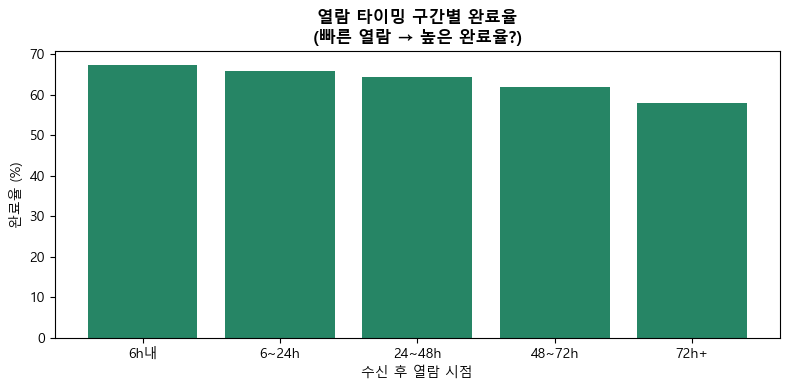

In [ ]:
# 열람 타이밍 구간 × 완료율
# "빨리 본 사람이 더 많이 완료하는가?"
# gap_to_view 구간을 나눠서 완료율 비교

viewed_df = funnel_clean[funnel_clean["is_viewed"] == True].copy()

bins = [0, 6, 24, 48, 72, float("inf")]
labels = ["6h내", "6~24h", "24~48h", "48~72h", "72h+"]
viewed_df["view_timing"] = pd.cut(viewed_df["gap_to_view"], bins=bins, labels=labels, right=True)

timing_summary = (
    viewed_df.groupby("view_timing", observed=True)
    .agg(n=("is_completed", "count"), completed=("is_completed", "sum"))
    .reset_index()
)
timing_summary["완료율(%)"] = (timing_summary["completed"] / timing_summary["n"] * 100).round(1)

for _, row in timing_summary.iterrows():
    lo, hi = proportion_confint(int(row["completed"]), int(row["n"]), method="wilson")
    print(
        f"  {row['view_timing']:<8} 완료율 {row['완료율(%)']:.1f}%  "
        f"95%CI [{lo*100:.1f}%, {hi*100:.1f}%]  (n={int(row['n']):,})"
    )

# 시각화
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(timing_summary["view_timing"].astype(str), timing_summary["완료율(%)"], color="#00704A", alpha=0.85)
ax.set_title("열람 타이밍 구간별 완료율\n(빠른 열람 → 높은 완료율?)", fontweight="bold")
ax.set_xlabel("수신 후 열람 시점")
ax.set_ylabel("완료율 (%)")
plt.tight_layout()
plt.show()

In [ ]:
# 반복 수신 효과 분석
# 같은 오퍼를 몇 번째 수신했을 때 처음 열람하는가
# → "반복 노출의 추가 효율이 초기 노출보다 낮은지" 탐색

first_view_inst = (
    funnel_clean[funnel_clean["is_viewed"] == True]
    .groupby(["customer_id", "offer_id"])["instance_id"]
    .min()
    .reset_index(name="first_viewed_instance")
)

inst_dist = first_view_inst["first_viewed_instance"].value_counts().sort_index()
inst_pct = (inst_dist / inst_dist.sum() * 100).round(2)

print("[ 오퍼를 처음 열람한 수신 회차 ]")
for inst, cnt in inst_dist.items():
    print(f"  {inst}회차 수신 시 첫 열람: {cnt:,}건 ({inst_pct[inst]:.1f}%)")
print("※ 발표 표현: '반복 노출의 추가 효율이 초기 노출보다 낮은 경향 관찰'")

[ 오퍼를 처음 열람한 수신 회차 ]
  1회차 수신 시 첫 열람: 33,542건 (97.9%)
  2회차 수신 시 첫 열람: 693건 (2.0%)
  3회차 수신 시 첫 열람: 19건 (0.1%)
  4회차 수신 시 첫 열람: 1건 (0.0%)
※ 발표 표현: '반복 노출의 추가 효율이 초기 노출보다 낮은 경향 관찰'


1. Segmentation (어떤 고객)
소득이 가장 강한 세그먼트 변수 (V=0.24) 
- 고소득(7.5만+): 완료율 72~76%, 주력 타겟 
- 저소득(5만 미만): 완료율 43%, 체감 혜택 큰 오퍼

2. Channel Mix (어떤 채널)
채널 수 ↑ → 완료율 ↑ (2개 48.8% → 4개 64.7%) 
- 채널 다양화가 전환율에 유의미한 영향

3. Offer Optimization (어떤 오퍼) 
전 세그먼트 discount 우세
- BOGO는 discount보다 0.8일 빠르게 완료
- discount는 완료율 자체가 높음

4. Cadence / Timing (어떤 간격)
수신 후 6시간 내 열람이 이후 완료율 가장 높은 경향
-  초기 노출 효율 > 반복 노출 효율

5. 시뮬레이터: 세그먼트 입력 → 오퍼 + CI 추천
- "조건별 결과를 비교하는 의사결정 지원 도구"   

### 채널 수 × 완료율

,채널 수,n,완료율(%),CI_low,CI_high
0,2개,6726,48.80,47.60,49.90
1,3개,19999,58.00,57.30,58.70
2,4개,26476,64.70,64.10,65.20


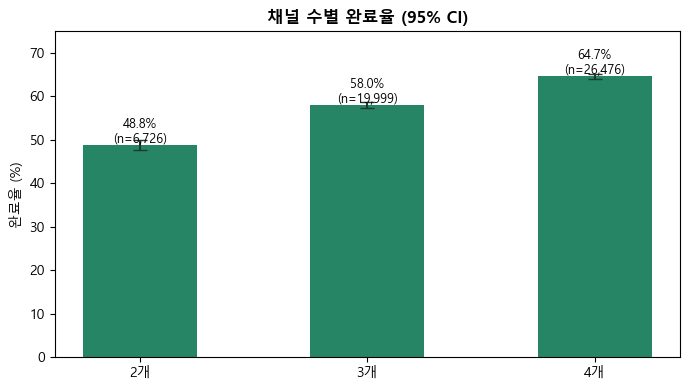

채널 2개 vs 1개: +9.2%p
채널 3개 vs 2개: +6.7%p


In [13]:
def channel_completion_summary(df: pd.DataFrame):
    """채널 수별 완료율 + 95% CI 테이블 반환"""
    rows = []
    for ch in sorted(df["channel_count"].dropna().unique()):
        sub = df[df["channel_count"] == ch]
        n, k = len(sub), sub["is_completed"].sum()
        rate = k / n * 100
        lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson")
        rows.append(
            {
                "채널 수": f"{int(ch)}개",
                "n": n,
                "완료율(%)": round(rate, 1),
                "CI_low": round(lo * 100, 1),
                "CI_high": round(hi * 100, 1),
            }
        )
    return pd.DataFrame(rows)


ch_summary = channel_completion_summary(funnel_clean)
display(ch_summary)

# 시각화
fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(ch_summary))
bars = ax.bar(x, ch_summary["완료율(%)"], color="#00704A", alpha=0.85, width=0.5)
ax.errorbar(
    x,
    ch_summary["완료율(%)"],
    yerr=[ch_summary["완료율(%)"] - ch_summary["CI_low"], ch_summary["CI_high"] - ch_summary["완료율(%)"]],
    fmt="none",
    color="#1E3932",
    capsize=5,
    linewidth=1.5,
)
for bar, row in zip(bars, ch_summary.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{row._3:.1f}%\n(n={row.n:,})",
        ha="center",
        fontsize=9,
    )
ax.set_xticks(list(x))
ax.set_xticklabels(ch_summary["채널 수"])
ax.set_title("채널 수별 완료율 (95% CI)", fontweight="bold")
ax.set_ylabel("완료율 (%)")
ax.set_ylim(0, ch_summary["CI_high"].max() * 1.15)
plt.tight_layout()
plt.show()

# 채널 간 완료율 증가폭
rates = ch_summary["완료율(%)"].values
for i in range(1, len(rates)):
    print(f"채널 {i+1}개 vs {i}개: +{rates[i]-rates[i-1]:.1f}%p")

--> 채널 수가 많을수록 완료율이 단계적으로 높아 "채널 다양화가 전환율에 유의미한 영향"

## 오퍼 속성(reward, difficulty) 분석

### | 오퍼 속성(reward, difficulty)과 완료율 상관관계

In [ ]:
#### is_aware 생성 로직
# funnel_instance["valid_view_sequence"] = (
#    funnel_instance["t_viewed"].notna()
#    & funnel_instance["t_completed"].notna()
#    & (funnel_instance["t_viewed"] <= funnel_instance["t_completed"])
# )
# funnel_instance["is_aware"] = funnel_instance["valid_view_sequence"].astype(int)

#### aware_rate 계산 공식
aware_rate (%) = (오퍼 인지 후 완료한 건수) / (해당 오퍼 전체 수신 건수) × 100

- 분모 (n): 특정 오퍼를 발송받은(received) 전체 횟수

- 분자 (aware): 전체 수신 건 중, 고객이 프로모션을 먼저 열람하고(viewed) 그 이후에 결제 조건을 달성(completed)한 건수

In [14]:
def offer_profile(df: pd.DataFrame) -> pd.DataFrame:
    """오퍼별 완료율 / 인지율 / 미인지 완료율 집계"""
    agg = (
        df.groupby("offer_id")
        .agg(
            offer_type=("offer_type", "first"),
            reward=("reward", "first"),
            difficulty=("difficulty", "first"),
            channel_count=("channel_count", "first"),
            n=("is_completed", "count"),
            completed=("is_completed", "sum"),
            aware=("is_aware", "sum"),
        )
        .reset_index()
    )
    agg["completion_rate"] = agg["completed"] / agg["n"] * 100
    agg["aware_rate"] = agg["aware"] / agg["n"] * 100
    agg["unaware_rate"] = agg["completion_rate"] - agg["aware_rate"]  # 미인지 완료 비율
    return agg.sort_values("completion_rate", ascending=False)


offer_profile_df = offer_profile(funnel_clean)
display(
    offer_profile_df[
        [
            "offer_id",
            "offer_type",
            "reward",
            "difficulty",
            "channel_count",
            "n",
            "completion_rate",
            "aware_rate",
            "unaware_rate",
        ]
    ].assign(offer_id=lambda x: x["offer_id"].str[:8])
)

print("\n[인사이트]")
for _, row in offer_profile_df.iterrows():
    flag = "⚠ 미인지 완료 多" if row["unaware_rate"] > 20 else ""
    print(
        f"  {row['offer_id'][:8]}  {row['offer_type']:<9}"
        f"  완료율 {row['completion_rate']:.1f}%  "
        f"인지율 {row['aware_rate']:.1f}%  "
        f"미인지완료 {row['unaware_rate']:.1f}%p  {flag}"
    )

,offer_id,offer_type,reward,difficulty,channel_count,n,completion_rate,aware_rate,unaware_rate
7,fafdcd66,discount,2.00,10.00,4.00,6652,74.10,64.46,9.64
1,2298d6c3,discount,3.00,7.00,4.00,6655,72.71,61.53,11.18
6,f19421c1,bogo,5.00,5.00,4.00,6576,61.95,51.00,10.95
4,9b98b8c7,bogo,5.00,5.00,3.00,6685,61.94,30.22,31.73
2,2906b810,discount,2.00,10.00,3.00,6631,58.11,30.51,27.60
5,ae264e36,bogo,10.00,10.00,3.00,6683,53.93,38.22,15.71
3,4d5c57ea,bogo,10.00,10.00,4.00,6593,49.76,41.24,8.52
0,0b1e1539,discount,5.00,20.00,2.00,6726,48.75,19.05,29.71



[인사이트]
  fafdcd66  discount   완료율 74.1%  인지율 64.5%  미인지완료 9.6%p  
  2298d6c3  discount   완료율 72.7%  인지율 61.5%  미인지완료 11.2%p  
  f19421c1  bogo       완료율 62.0%  인지율 51.0%  미인지완료 10.9%p  
  9b98b8c7  bogo       완료율 61.9%  인지율 30.2%  미인지완료 31.7%p  ⚠ 미인지 완료 多
  2906b810  discount   완료율 58.1%  인지율 30.5%  미인지완료 27.6%p  ⚠ 미인지 완료 多
  ae264e36  bogo       완료율 53.9%  인지율 38.2%  미인지완료 15.7%p  
  4d5c57ea  bogo       완료율 49.8%  인지율 41.2%  미인지완료 8.5%p  
  0b1e1539  discount   완료율 48.8%  인지율 19.0%  미인지완료 29.7%p  ⚠ 미인지 완료 多


오퍼 속성 분석
- 1위 fafdcd66  discount  reward=2  difficulty=10  채널4  완료율 74.1%  인지율 64.5%
- 2위 2298d6c3  discount  reward=3  difficulty=7   채널4  완료율 72.7%  인지율 61.5%

completion_rate vs aware_rate 차이
- fafdcd66: 완료율 74.1%  인지율 64.5%  → 차이 9.6%p (미인지 완료 多)
- 9b98b8c7: 완료율 61.9%  인지율 30.2%  → 차이 31.7%p (미인지 완료 매우 多)

9b98b8c7 (bogo, reward=5, difficulty=5) 는 완료율은 높지만 인지율이 매우 낮음. 
--> 오퍼를 보지 않고도 자연스럽게 달성되는 케이스가 많다는 뜻.

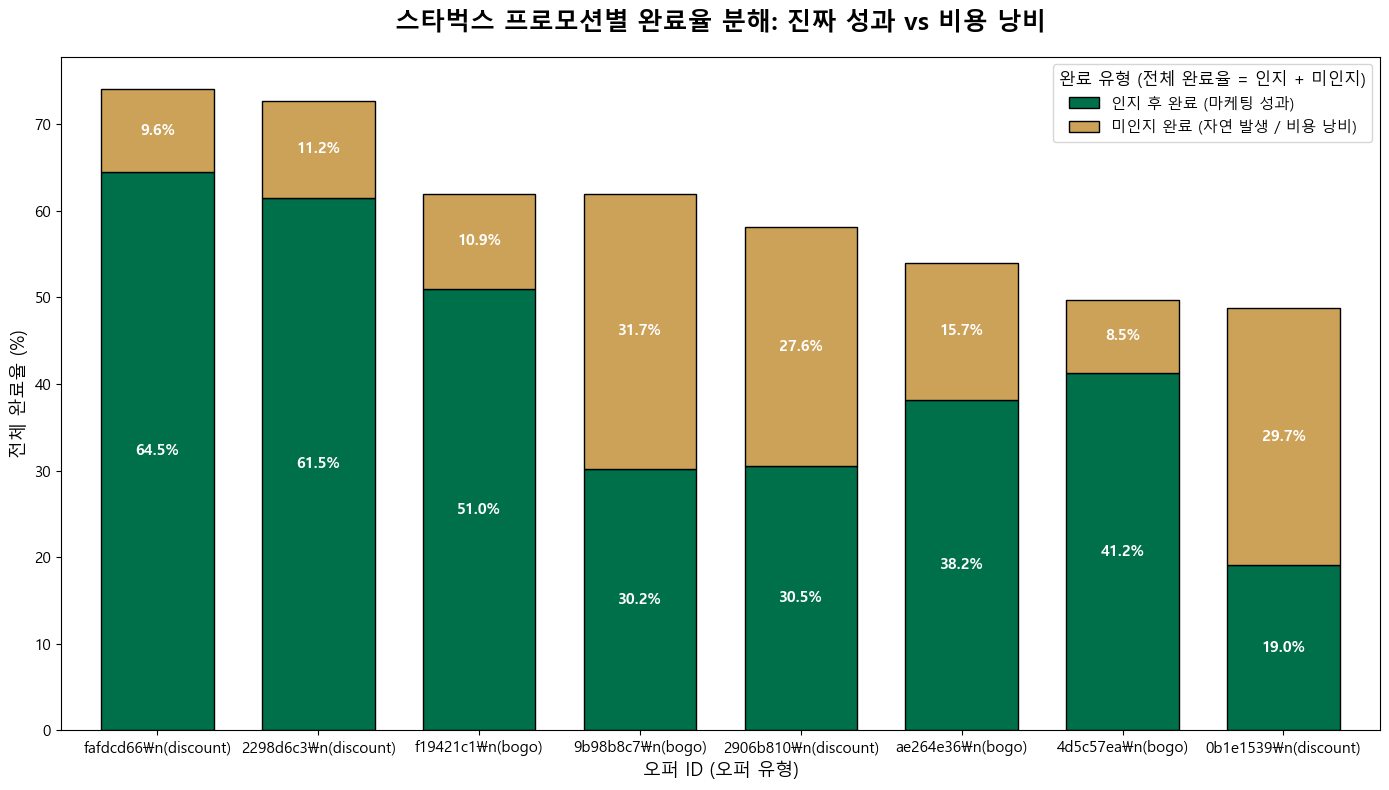

In [ ]:
plot_df = (
    offer_profile_df.assign(offer_label=lambda x: x["offer_id"].str[:8] + "\\n(" + x["offer_type"] + ")")
    .set_index("offer_label")[["aware_rate", "unaware_rate"]]
    .rename(columns={"aware_rate": "인지 후 완료 (마케팅 성과)", "unaware_rate": "미인지 완료 (자연 발생 / 비용 낭비)"})
)

# 누적 막대 그래프 (Stacked Bar Chart) 그리기
# 색상 지정: 성과는 초록색(#2ca02c), 낭비는 붉은색(#d62728)
ax = plot_df.plot(kind="bar", stacked=True, figsize=(14, 8), color=["#00704A", "#CBA258"], edgecolor="black", width=0.7)

plt.title("스타벅스 프로모션별 완료율 분해: 진짜 성과 vs 비용 낭비", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("오퍼 ID (오퍼 유형)", fontsize=13)
plt.ylabel("전체 완료율 (%)", fontsize=13)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="완료 유형 (전체 완료율 = 인지 + 미인지)", fontsize=11, title_fontsize=12, loc="upper right")

# 막대 내부에 데이터 수치(%) 텍스트 표시
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()

    # 비율이 2% 이상일 때만 텍스트 표시
    if height > 2.0:
        ax.text(
            x + width / 2,
            y + height / 2,
            f"{height:.1f}%",
            ha="center",
            va="center",
            color="white",
            fontsize=11,
            fontweight="bold",
        )

plt.tight_layout()
plt.show()

## 세그먼트별 완료율 히트맵

### | 세그먼트별 최적 오퍼 분석
"어떤 고객에게 어떤 오퍼가 효과적인가?"

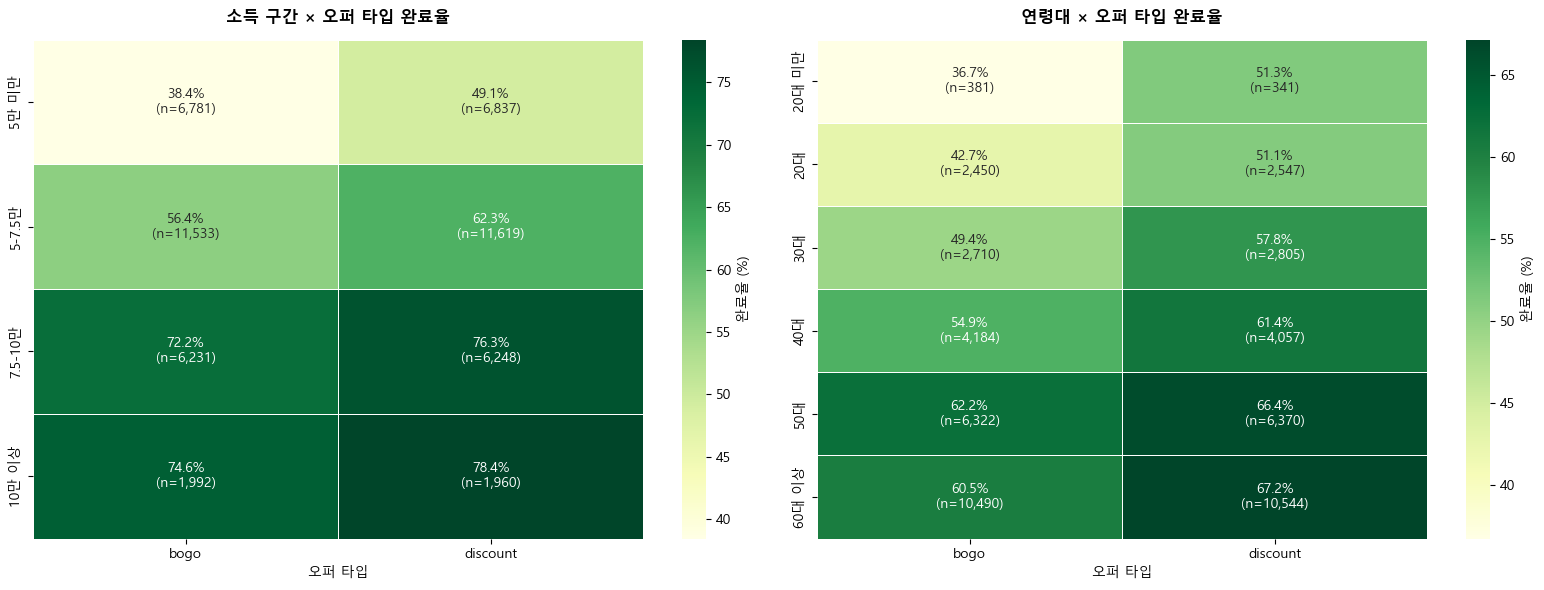


[ discount - bogo 완료율 차이 ]
  [소득]
    5만 미만      +10.7%p
    5-7.5만     +5.9%p
    7.5-10만    +4.1%p
    10만 이상     +3.8%p
  [연령]
    20대 미만     +14.6%p
    20대        +8.4%p
    30대        +8.4%p
    40대        +6.6%p
    50대        +4.2%p
    60대 이상     +6.7%p


In [15]:
def make_heatmap(df: pd.DataFrame, row_col: str, row_order: list, ax, title: str):
    """완료율 히트맵 + 셀 내 표본수 표시"""
    pivot = (df.groupby([row_col, "offer_type"])["is_completed"].mean().unstack() * 100).reindex(row_order)

    n_tbl = (df.groupby([row_col, "offer_type"])["is_completed"].count().unstack()).reindex(row_order)

    # 셀 어노테이션: 완료율 + 표본수
    annot = pivot.copy().astype(object)
    for r in row_order:
        for c in pivot.columns:
            rate = pivot.loc[r, c] if c in pivot.columns else float("nan")
            n = n_tbl.loc[r, c] if c in n_tbl.columns else 0
            annot.loc[r, c] = f"{rate:.1f}%\n(n={int(n):,})" if pd.notna(rate) else "-"

    sns.heatmap(pivot, annot=annot, fmt="", cmap="YlGn", ax=ax, linewidths=0.5, cbar_kws={"label": "완료율 (%)"})
    ax.set_title(title, fontweight="bold", pad=12)
    ax.set_xlabel("오퍼 타입")
    ax.set_ylabel("")
    return pivot


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot_inc = make_heatmap(funnel_clean, "income_group", INC_ORDER, axes[0], "소득 구간 × 오퍼 타입 완료율")
pivot_age = make_heatmap(funnel_clean, "age_group", AGE_ORDER, axes[1], "연령대 × 오퍼 타입 완료율")

plt.tight_layout()
plt.show()

# discount - bogo 완료율 차이
print("\n[ discount - bogo 완료율 차이 ]")
for pivot, order, label in [
    (pivot_inc, INC_ORDER, "소득"),
    (pivot_age, AGE_ORDER, "연령"),
]:
    if "bogo" in pivot.columns and "discount" in pivot.columns:
        diff = pivot["discount"] - pivot["bogo"]
        print(f"  [{label}]")
        for idx, d in diff.items():
            print(f"    {idx:<10} {d:+.1f}%p")

### 통계 검정 (카이제곱 + Cramér's V)

In [16]:
def cramers_v(chi2: float, n: int, k: int) -> float:
    """
    Cramér's V 효과 크기
    V < 0.1        : 약함
    0.1 <= V < 0.3 : 중간
    V >= 0.3       : 강함
    """
    return np.sqrt(chi2 / (n * (k - 1)))


def chi2_test(df: pd.DataFrame, group_col: str, target_col: str = "is_completed", label: str = "") -> dict:
    """
    카이제곱 독립성 검정 + Cramér's V + 그룹별 완료율 + 95% CI

    Parameters
    ----------
    df         : 분석 대상 DataFrame
    group_col  : 독립변수 컬럼명
    target_col : 종속변수 컬럼명 (기본: is_completed)
    label      : 출력 레이블

    Returns
    -------
    dict : 검정 결과 요약
    """
    ct = pd.crosstab(df[group_col], df[target_col])
    chi2_stat, p, dof, expected = stats.chi2_contingency(ct)
    n = ct.values.sum()
    v = cramers_v(chi2_stat, n, min(ct.shape))
    effect = "강함" if v >= 0.3 else "중간" if v >= 0.1 else "약함"

    print(f"\n{'='*55}")
    print(f"[{label}]  {group_col} × {target_col}")
    print(f"{'='*55}")
    print(f"  기대빈도 최솟값: {expected.min():.1f}  " f"{'(>=5 OK)' if expected.min() >= 5 else '(<5 해석 주의)'}")
    print(f"  χ²={chi2_stat:.2f}  df={dof}  p={p:.2e}")
    print(f"  Cramér`s V={v:.3f}  효과 크기: {effect}")
    print(f"  → {'✅ 유의 (p<0.05)' if p < 0.05 else '❌ 비유의 (p>=0.05)'}")

    print("\n  그룹별 완료율:")
    for grp, grp_df in df.groupby(group_col):
        n_g, k_g = len(grp_df), grp_df[target_col].sum()
        rate = k_g / n_g * 100
        lo, hi = proportion_confint(k_g, n_g, alpha=0.05, method="wilson")
        print(f"    {str(grp):<12} {rate:.1f}%  " f"95%CI [{lo*100:.1f}%, {hi*100:.1f}%]  (n={n_g:,})")

    return {
        "변수": label,
        "χ²": round(chi2_stat, 2),
        "p값": f"{p:.2e}",
        "V": round(v, 3),
        "효과크기": effect,
        "유의": "✅" if p < 0.05 else "❌",
    }

In [17]:
results = []

# 1. 소득 구간
df_inc = funnel_clean[funnel_clean["income_group"].isin(INC_ORDER)].copy()
df_inc["income_group"] = pd.Categorical(df_inc["income_group"], categories=INC_ORDER, ordered=True)
results.append(chi2_test(df_inc, "income_group", label="소득 구간"))

# 2. 연령대
df_age = funnel_clean[funnel_clean["age_group"].isin(AGE_ORDER)].copy()
df_age["age_group"] = pd.Categorical(df_age["age_group"], categories=AGE_ORDER, ordered=True)
results.append(chi2_test(df_age, "age_group", label="연령대"))

# 3. 성별
df_gen = funnel_clean[funnel_clean["gender"].isin(["M", "F", "O"])].copy()
results.append(chi2_test(df_gen, "gender", label="성별"))

# 4. 오퍼 타입
results.append(chi2_test(funnel_clean, "offer_type", label="오퍼 타입"))

# 5. 채널 수
df_ch = funnel_clean[funnel_clean["channel_count"].notna()].copy()
df_ch["channel_count"] = df_ch["channel_count"].astype(int).astype(str) + "개"
results.append(chi2_test(df_ch, "channel_count", label="채널 수"))


[소득 구간]  income_group × is_completed
  기대빈도 최솟값: 1574.9  (>=5 OK)
  χ²=3006.33  df=3  p=0.00e+00
  Cramér`s V=0.238  효과 크기: 중간
  → ✅ 유의 (p<0.05)

  그룹별 완료율:
    5만 미만        43.8%  95%CI [43.0%, 44.6%]  (n=13,618)
    5-7.5만       59.4%  95%CI [58.7%, 60.0%]  (n=23,152)
    7.5-10만      74.3%  95%CI [73.5%, 75.0%]  (n=12,479)
    10만 이상       76.5%  95%CI [75.2%, 77.8%]  (n=3,952)

[연령대]  age_group × is_completed
  기대빈도 최솟값: 287.7  (>=5 OK)
  χ²=766.43  df=5  p=2.11e-163
  Cramér`s V=0.120  효과 크기: 중간
  → ✅ 유의 (p<0.05)

  그룹별 완료율:
    20대 미만       43.6%  95%CI [40.1%, 47.3%]  (n=722)
    20대          47.0%  95%CI [45.6%, 48.4%]  (n=4,997)
    30대          53.7%  95%CI [52.4%, 55.0%]  (n=5,515)
    40대          58.1%  95%CI [57.0%, 59.2%]  (n=8,241)
    50대          64.3%  95%CI [63.5%, 65.1%]  (n=12,692)
    60대 이상       63.8%  95%CI [63.2%, 64.5%]  (n=21,034)

[성별]  gender × is_completed
  기대빈도 최솟값: 287.3  (>=5 OK)
  χ²=1515.05  df=2  p=0.00e+00
  Cramér`s V=0.169  효과 크기: 중간
  → ✅ 유의 

In [18]:
# 결과 요약 테이블
print(f"\n{'='*55}")
print("[ 통계 검정 결과 요약 ]")
print(f"{'='*55}")
display(pd.DataFrame(results))

print(
    """
[Cramér's V 해석 기준]
  V < 0.1        → 약한 연관성
  0.1 ≤ V < 0.3  → 중간 연관성
  V ≥ 0.3        → 강한 연관성

[주의 사항]
  - 카이제곱은 독립성 검증 (인과관계 아님)
  - 표본이 크면 작은 차이도 유의하게 나올 수 있음
    → V를 반드시 함께 봐야 실질적 의미 판단 가능
  - 같은 고객이 여러 인스턴스로 반복 등장
    → 완전한 독립성 가정 위배, 탐색적 근거로 활용
"""
)


[ 통계 검정 결과 요약 ]


,변수,χ²,p값,V,효과크기,유의
0,소득 구간,3006.33,0.00e+00,0.24,중간,✅
1,연령대,766.43,2.11e-163,0.12,중간,✅
2,성별,1515.05,0.00e+00,0.17,중간,✅
3,오퍼 타입,232.70,1.54e-52,0.07,약함,✅
4,채널 수,629.45,2.07e-137,0.11,중간,✅



[Cramér's V 해석 기준]
  V < 0.1        → 약한 연관성
  0.1 ≤ V < 0.3  → 중간 연관성
  V ≥ 0.3        → 강한 연관성

[주의 사항]
  - 카이제곱은 독립성 검증 (인과관계 아님)
  - 표본이 크면 작은 차이도 유의하게 나올 수 있음
    → V를 반드시 함께 봐야 실질적 의미 판단 가능
  - 같은 고객이 여러 인스턴스로 반복 등장
    → 완전한 독립성 가정 위배, 탐색적 근거로 활용



### 오퍼 추천 시뮬레이터

### | 시뮬레이터 설계
"세그먼트 입력 → 최적 오퍼 추천"

In [19]:
def recommend_offer(
    gender: str,
    age_group: str,
    income_group: str,
    min_n: int = 30,
    alpha: float = 0.05,
) -> pd.DataFrame:
    """
    고객 세그먼트 입력 → 완료율 기준 오퍼 추천

    Parameters
    ----------
    gender       : 'M' | 'F' | 'O'
    age_group    : '20대' | '30대' | ...
    income_group : '5만 미만' | '5-7.5만' | ...
    min_n        : 표본 부족 경고 기준 (기본 30)
    alpha        : 신뢰구간 유의수준 (기본 0.05 → 95% CI)

    Returns
    -------
    DataFrame : 오퍼별 완료율 + CI + 추천 여부
    """
    seg = funnel_clean[
        (funnel_clean["gender"] == gender)
        & (funnel_clean["age_group"] == age_group)
        & (funnel_clean["income_group"] == income_group)
    ]

    if len(seg) == 0:
        print(f"[경고] {gender} / {age_group} / {income_group} 세그먼트 데이터 없음")
        return pd.DataFrame()

    rows = []
    for offer_id, grp in seg.groupby("offer_id"):
        n, k = len(grp), grp["is_completed"].sum()
        rate = k / n * 100
        lo, hi = proportion_confint(k, n, alpha=alpha, method="wilson")
        rows.append(
            {
                "offer_id": offer_id[:8],
                "offer_type": grp["offer_type"].iloc[0],
                "channel_count": int(grp["channel_count"].iloc[0]),
                "reward": grp["reward"].iloc[0],
                "difficulty": grp["difficulty"].iloc[0],
                "n": n,
                "completion_rate": round(rate, 1),
                "CI_low": round(lo * 100, 1),
                "CI_high": round(hi * 100, 1),
                "주의": "⚠ 표본 부족" if n < min_n else "",
            }
        )

    result = pd.DataFrame(rows).sort_values("completion_rate", ascending=False).reset_index(drop=True)
    result.index += 1  # 1위부터 시작

    print(f"세그먼트: {gender} / {age_group} / {income_group}  " f"(전체 {len(seg):,}건)")
    return result


# 실행 예시
display(recommend_offer(gender="F", age_group="40대", income_group="5-7.5만"))

세그먼트: F / 40대 / 5-7.5만  (전체 1,562건)


,offer_id,offer_type,channel_count,reward,difficulty,n,completion_rate,CI_low,CI_high,주의
1,fafdcd66,discount,4,2.00,10.00,189,81.50,75.30,86.40,
2,2298d6c3,discount,4,3.00,7.00,205,81.00,75.10,85.80,
3,2906b810,discount,3,2.00,10.00,189,72.50,65.70,78.40,
4,9b98b8c7,bogo,3,5.00,5.00,187,70.60,63.70,76.70,
5,f19421c1,bogo,4,5.00,5.00,198,68.20,61.40,74.30,
6,ae264e36,bogo,3,10.00,10.00,199,67.80,61.10,73.90,
7,4d5c57ea,bogo,4,10.00,10.00,197,65.50,58.60,71.80,
8,0b1e1539,discount,2,5.00,20.00,198,59.10,52.10,65.70,


- 20대 미만  → bogo 36.7%  discount 51.3%  (discount 큰 격차)
- 50대       → bogo 62.2%  discount 66.4%  (격차 좁아짐)
- 60대 이상  → bogo 60.5%  discount 67.2%
- → 전 연령대 discount 우세, 젊을수록 격차 큼

In [20]:
# 여러 세그먼트 일괄 비교
segments = [
    ("F", "40대", "5-7.5만"),
    ("M", "50대", "7.5-10만"),
    ("F", "20대", "5만 미만"),
]

top1_rows = []
for gender, age, income in segments:
    res = recommend_offer(gender, age, income)
    if len(res) > 0:
        top = res.iloc[0]
        top1_rows.append(
            {
                "세그먼트": f"{gender}/{age}/{income}",
                "추천 오퍼": top["offer_id"],
                "오퍼 타입": top["offer_type"],
                "완료율(%)": top["completion_rate"],
                "CI": f"[{top['CI_low']}, {top['CI_high']}]",
                "n": top["n"],
            }
        )

print("\n[ 세그먼트별 1위 추천 오퍼 요약 ]")
display(pd.DataFrame(top1_rows))

세그먼트: F / 40대 / 5-7.5만  (전체 1,562건)
세그먼트: M / 50대 / 7.5-10만  (전체 1,795건)
세그먼트: F / 20대 / 5만 미만  (전체 636건)

[ 세그먼트별 1위 추천 오퍼 요약 ]


,세그먼트,추천 오퍼,오퍼 타입,완료율(%),CI,n
0,F/40대/5-7.5만,fafdcd66,discount,81.50,"[75.3, 86.4]",189
1,M/50대/7.5-10만,fafdcd66,discount,84.40,"[78.9, 88.7]",212
2,F/20대/5만 미만,2298d6c3,discount,84.50,"[75.3, 90.7]",84
